# 🧪 Lab Workbook: Phosphate Calibration
### Experiment 1D -- Environmental Audit of Possible Phosphate Contamination

**Model answers** -- example submission with realistic data (for demonstrators / self-checking).

Developed by Valentina Erastova, University of Edinburgh

---

**Example student:** _____ Great Chemist _____    

**Date:** _____ 17 June 2026 _____


---
## How to use this notebook

**Recommended environment:** Edina Noteable (`Standard Python 3` kernel) -- https://noteable.edina.ac.uk/launch

1. Open this notebook in Noteable (or VS Code / JupyterLab locally).
2. Select the **Python 3** kernel if prompted.
3. Run cells with **Shift + Enter**.
4. **Replace the example data** with your own lab notebook values.
5. For AI help, open **ELM** in another tab: https://elm.edina.ac.uk/elm/elm
6. Copy the prompts from this notebook into ELM -- do not paste your whole notebook.
7. Always check: do the units, concentrations, and plot trends make chemical sense?

**Getting this notebook from Git:**
```text
git clone https://github.com/Erastova-group/PgT-Python-Vibe.git
```
Then open `Phosphate/phosphate_calibration_workbook.ipynb`.


---
## 🔄 Quick reminder -- skills from the workshop

You already learned enough to do this analysis. Here is what you will use again:

| Skill | Where you use it here |
|---|---|
| Variables and units | Storing concentrations, absorbances, loch volume |
| Lists / `pandas` tables | Organising replicate absorbance readings |
| `matplotlib` plots | Calibration graph (absorbance vs concentration) |
| Linear fit + $R^2$ | Finding the best-fit line through standards |
| Rearranging an equation | Using the calibration line to find unknown concentrations |
| ELM vibe coding | Generating or fixing code when you are stuck |

### Beer-Lambert law (the chemistry behind the plot)

$A = \epsilon l c$

- $A$ = absorbance (from the spectrophotometer at 880 nm)
- $\epsilon$ = molar extinction coefficient
- $l$ = path length of the cuvette (usually 1 cm)
- $c$ = concentration of phosphate in the coloured solution

If path length is constant, absorbance should increase **linearly** with concentration. Your calibration graph tests this -- a straight line with $R^2$ close to 1 is a good sign.

### ELM workflow (same as the workshop)
1. **Prompt** -- paste a specific prompt from this notebook
2. **Paste** -- copy useful code into the empty cell below the prompt
3. **Run** -- Shift + Enter
4. **Read** -- check variable names and units before trusting the output
5. **Iterate** -- if something looks wrong, paste the error or describe the problem back to ELM

> **Tip:** Ask ELM for *"beginner-friendly Python code for a Jupyter notebook"* and name your CSV columns or variables exactly as in this notebook.



---
## 📋 Experiment recap

**Aim:** Determine phosphate concentration in a diluted cow urine sample using UV-Vis spectroscopy (blue molybdate complex, $\lambda_{\mathrm{max}} \approx$ 880 nm).

**Part 1 -- Standards:** Pipette 2, 4, 6, 8, and 10 c$\text{m}^3$ of stock standard into separate 50 c$\text{m}^3$ volumetric flasks (+ one blank). Add molybdate and Sn(II) reagents, dilute to the mark, wait 30 min, measure absorbance at 880 nm.

**Part 2 -- Unknown:** Cow urine was **pre-diluted $\times 10$** before you received it. Pipette 10 c$\text{m}^3$ into 50 c$\text{m}^3$ flasks (triplicate), treat as for standards, measure absorbance.

**Stock standard concentration:** $2.00 \times 10^{-3}\ \text{mg mL}^{-1}$

**Environmental question (after analysis):** 100 cows each produce ~13 L urine/day. If all urine reaches Loch of the Lowes (volume $5.5 \times 10^{6}\text{ m}^3$, initial phosphate $5.00\ \mu\text{g L}^{-1}$), how long until phosphate exceeds the SEPA safe limit of **$0.025\ \text{mg L}^{-1}$**?



---
## Step 1 -- Calculate standard concentrations

Before plotting, confirm you know the phosphate concentration in each standard flask.

Use dilution: **$C_1 V_1 = C_2 V_2$**

- Stock concentration: $2.00 \times 10^{-3}\ \text{mg mL}^{-1}$ = **$2.00\ \text{mg L}^{-1}$**
- Final volume in each flask: **50.0 mL**
- Volumes of stock pipetted: 0 (blank), 2, 4, 6, 8, 10 mL

**✏️ Exercise:** Work out each standard concentration in **$\text{mg L}^{-1}$** in your lab book first. Then run the cell below to check.



In [1]:
# Check standard concentrations
stock_conc_mg_per_L = 2.00e-3 * 1000
final_volume_mL = 50.0
pipette_volumes_mL = [0, 2, 4, 6, 8, 10]
standard_conc_mg_per_L = [stock_conc_mg_per_L * (v / final_volume_mL) for v in pipette_volumes_mL]
for v, c in zip(pipette_volumes_mL, standard_conc_mg_per_L):
    print(f"{v:2d} mL stock -> {c:.3f} mg/L phosphate in standard")



 0 mL stock -> 0.000 mg/L phosphate in standard
 2 mL stock -> 0.080 mg/L phosphate in standard
 4 mL stock -> 0.160 mg/L phosphate in standard
 6 mL stock -> 0.240 mg/L phosphate in standard
 8 mL stock -> 0.320 mg/L phosphate in standard
10 mL stock -> 0.400 mg/L phosphate in standard


---
## Step 2 -- Enter your experimental data

Replace the **example** absorbance values below with your own from the lab notebook.

- Standards: one absorbance per flask (blank + five standards)
- Unknowns: three replicate absorbance readings for the treated urine samples

Keep concentrations in **$\text{mg L}^{-1}$** to match the lab handout.



In [2]:
import pandas as pd
from IPython.display import display

standards = pd.DataFrame({
    'flask': ['blank', 'std_2mL', 'std_4mL', 'std_6mL', 'std_8mL', 'std_10mL'],
    'stock_pipetted_mL': [0, 2, 4, 6, 8, 10],
    'concentration_mg_per_L': standard_conc_mg_per_L,
    'absorbance_880nm': [0.003, 0.049, 0.096, 0.143, 0.190, 0.237],
})
unknowns = pd.DataFrame({
    'replicate': ['rep_1', 'rep_2', 'rep_3'],
    'absorbance_880nm': [0.250, 0.253, 0.248],
})
print('Standards:')
display(standards)
print('\nUnknowns:')
display(unknowns)


Standards:


,flask,stock_pipetted_mL,concentration_mg_per_L,absorbance_880nm
0,blank,0,0.00,0.003
1,std_2mL,2,0.08,0.049
2,std_4mL,4,0.16,0.096
3,std_6mL,6,0.24,0.143
4,std_8mL,8,0.32,0.190
5,std_10mL,10,0.40,0.237



Unknowns:


,replicate,absorbance_880nm
0,rep_1,0.250
1,rep_2,0.253
2,rep_3,0.248


---
## Step 3 -- Plot the calibration curve

Plot **absorbance (y-axis)** vs **concentration (x-axis)** for the standards.

A good calibration curve should:
- Pass near the origin (blank $\approx$ zero absorbance)
- Show a roughly straight line through the points
- Have standards in order of increasing absorbance

Run the cell below, then check the plot against your lab notebook.



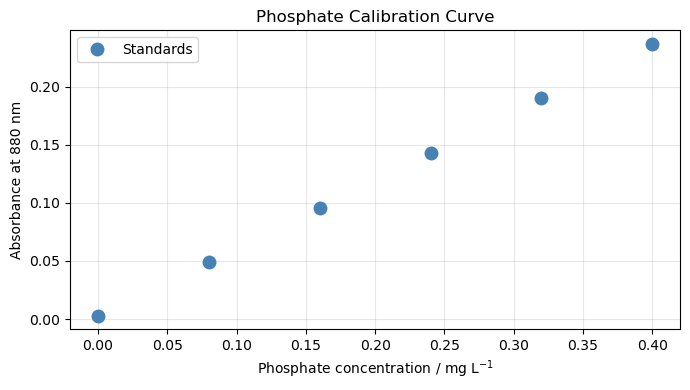

In [3]:
import matplotlib.pyplot as plt
import numpy as np
x = standards['concentration_mg_per_L']
y = standards['absorbance_880nm']
plt.figure(figsize=(7, 4))
plt.plot(x, y, 'o', color='steelblue', markersize=9, label='Standards')
plt.xlabel(r'Phosphate concentration / $\text{mg L}^{-1}$')
plt.ylabel(r'Absorbance at 880 nm')
plt.title('Phosphate Calibration Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



### 🤖 Stuck on the plot? Paste this into ELM:

> *I am a chemistry student using a Python 3 Jupyter notebook. I have a pandas dataframe called `standards` with columns `concentration_mg_per_L` and `absorbance_880nm`. Write beginner-friendly code to plot absorbance vs concentration with clear axis labels, a title, and grid lines. Use matplotlib.*

---
## Step 4 -- Fit a straight line and find $R^2$

Fit a linear trendline to the standards (excluding obvious outliers if your demonstrator advises).

- **Slope** -- how much absorbance changes per $\text{mg L}^{-1}$
- **Intercept** -- should be close to zero for a good blank
- **$R^2$** -- closeness to 1 means a good linear fit

Equation of the line: **$A = mc + b$**



Calibration equation: A = 0.5857 x c + 0.0025
R^2 = 1.0000


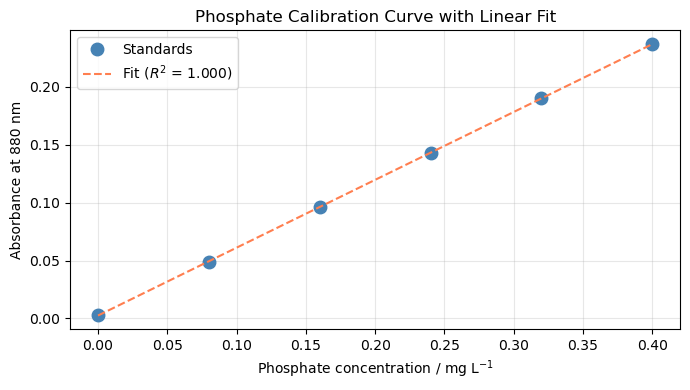

In [4]:
slope, intercept = np.polyfit(x, y, 1)
predicted = slope * x + intercept
ss_res = ((y - predicted) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r_squared = 1 - (ss_res / ss_tot)
print(f'Calibration equation: A = {slope:.4f} x c + {intercept:.4f}')
print(f'R^2 = {r_squared:.4f}')
x_line = np.linspace(x.min(), x.max(), 100)
plt.figure(figsize=(7, 4))
plt.plot(x, y, 'o', color='steelblue', markersize=9, label='Standards')
plt.plot(x_line, slope * x_line + intercept, '--', color='coral', label=f'Fit ($R^2$ = {r_squared:.3f})')
plt.xlabel(r'Phosphate concentration / $\text{mg L}^{-1}$')
plt.ylabel(r'Absorbance at 880 nm')
plt.title('Phosphate Calibration Curve with Linear Fit')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



**🧠 Critical thinking pause:**
- Does the line pass through your points?
- Is $R^2$ close to 1?
- Is the intercept near zero? If not, could the blank be wrong or is there a systematic offset?

### 🤖 ELM prompt for linear fit:

> *I have standard concentrations in `standards['concentration_mg_per_L']` and absorbances in `standards['absorbance_880nm']`. Write Python code using numpy to fit a straight line, print the slope, intercept, and $R^2$, and overlay the fit on the calibration plot.*



---
## Step 5 -- Concentration of phosphate in the unknown solutions

Rearrange the calibration equation to find concentration from absorbance:

$c = (A - \mathrm{intercept}) / \mathrm{slope}$

This gives the phosphate concentration in the **50 mL treated flask** (after you pipetted 10 mL of pre-diluted urine and diluted to the mark).

Then account for **all dilution factors** to get the concentration in the **original cow urine**:

1. Urine was pre-diluted **$\times 10$** before you received it
2. You pipetted **10 mL** of that into a **50 mL** flask $\rightarrow$ another **$\times 5$** dilution

So: **concentration in original urine = measured c $\times$ 10 $\times$ 5 = measured c $\times$ 50**



In [5]:
unknowns['conc_in_flask_mg_per_L'] = (unknowns['absorbance_880nm'] - intercept) / slope
mean_conc_flask = unknowns['conc_in_flask_mg_per_L'].mean()
std_conc_flask = unknowns['conc_in_flask_mg_per_L'].std()
dilution_factor = 10 * (50 / 10)
conc_urine_mg_per_L = mean_conc_flask * dilution_factor
uncertainty_urine_mg_per_L = std_conc_flask * dilution_factor
print('Unknown results (concentration in treated 50 mL flasks):')
display(unknowns)
print(f"\nMean concentration in original cow urine: {conc_urine_mg_per_L:.3f} +/- {uncertainty_urine_mg_per_L:.3f} mg/L PO4^3-")



Unknown results (concentration in treated 50 mL flasks):


,replicate,absorbance_880nm,conc_in_flask_mg_per_L
0,rep_1,0.250,0.422520
1,rep_2,0.253,0.427642
2,rep_3,0.248,0.419106



Mean concentration in original cow urine: 21.154 +/- 0.215 mg/L PO4^3-


<details>
<summary><strong>Click to reveal how the dilution factor works</strong></summary>

If the treated flask concentration is $c_\mathrm{flask}$, the urine before the 10 mL $\rightarrow$ 50 mL step was $5 \times c_\mathrm{flask}$.
The original urine (before the $\times 10$ pre-dilution) was $50 \times c_\mathrm{flask}$.

Always trace dilutions step by step -- this is a common place to lose marks.

</details>

---
## Step 6 -- Environmental impact: Loch of the Lowes

**Given data:**
- Loch volume: $5.5 \times 10^{6}\text{ m}^3$
- Initial phosphate: $5.00\ \mu\text{g L}^{-1}$ = $0.005\ \text{mg L}^{-1}$
- Safe limit (SEPA): $0.025\ \text{mg L}^{-1}$
- 100 cows $\times$ 13 L urine per cow per day
- Assume **all** daily urine enters the loch and mixes instantly

**Strategy:**
1. Calculate mass of phosphate added per day from urine
2. Calculate the new loch concentration after each day's addition
3. Find how many days until concentration reaches $0.025\ \text{mg L}^{-1}$



In [6]:
loch_volume_m3 = 5.5e6
loch_volume_L = loch_volume_m3 * 1000
initial_conc_mg_per_L = 5.00e-6 * 1000
safe_limit_mg_per_L = 0.025
n_cows = 100
urine_per_cow_per_day_L = 13
daily_urine_volume_L = n_cows * urine_per_cow_per_day_L
urine_phosphate_mg_per_L = conc_urine_mg_per_L
daily_phosphate_added_mg = daily_urine_volume_L * urine_phosphate_mg_per_L
initial_mass_mg = initial_conc_mg_per_L * loch_volume_L
target_mass_mg = safe_limit_mg_per_L * loch_volume_L
mass_to_add_mg = target_mass_mg - initial_mass_mg
days_to_limit = mass_to_add_mg / daily_phosphate_added_mg
years_to_limit = days_to_limit / 365.25
print(f'Loch volume: {loch_volume_L:.2e} L')
print(f'Initial phosphate: {initial_conc_mg_per_L:.4f} mg/L')
print(f'Safe limit: {safe_limit_mg_per_L} mg/L')
print(f'Daily urine volume entering loch: {daily_urine_volume_L} L')
print(f'Daily phosphate added: {daily_phosphate_added_mg:.2e} mg')
print(f'\nEstimated time to reach safe limit: {days_to_limit:.0f} days ({years_to_limit:.1f} years)')



Loch volume: 5.50e+09 L
Initial phosphate: 0.0050 mg/L
Safe limit: 0.025 mg/L
Daily urine volume entering loch: 1300 L
Daily phosphate added: 2.75e+04 mg

Estimated time to reach safe limit: 4000 days (11.0 years)


---
## Step 7 -- Evaluation (example written answers)

1. **How realistic is the time estimate?** The estimate of ~11 years (4000 days) assumes all urine from 100 cows reaches the loch instantly and mixes uniformly, with no phosphate removal. In reality, urine may infiltrate soil, be taken up by plants, or enter groundwater slowly. Rainfall dilutes the loch, and phosphate can sediment or be consumed by algae. The true time could be much longer -- or shorter if urine concentrates in runoff after heavy rain.

2. **Precision:** The triplicate unknown absorbances (0.250, 0.253, 0.248) agree within ~2%, giving a small standard deviation. This suggests good technique, though spectrophotometer noise and timing of the 30-minute colour development could still contribute.

3. **Calibration quality:** $R^2 = 1.000$ confirms an excellent linear fit over $0$--$0.400\ \text{mg L}^{-1}$ ($A = 0.586c + 0.003$). The intercept is near zero, consistent with Beer-Lambert law. The blank absorbance (0.003) is small but non-zero, which is typical for reagent background.

4. **Missing information:** We were not told the loch's water turnover rate, whether cows are present year-round, phosphate removal mechanisms, other pollution sources, groundwater inflow/outflow, or the speciation of phosphate in urine vs. the measured $\mathrm{PO_4^{3-}}$ standard.

---
## ✅ Submission checklist (completed)

- [x] All data entered and cells run
- [x] Calibration plot and $R^2$ included
- [x] Urine concentration with dilution factors shown
- [x] Environmental estimate completed
- [x] Evaluation written

